In [1]:
import numpy as np
import pandas as pd
import os

# Traverse files but do not print
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        pass  # Do nothing

In [2]:
import os
import random

dataset_path = '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset'

# Get only class folders
classes = [cls for cls in os.listdir(dataset_path) 
           if os.path.isdir(os.path.join(dataset_path, cls))]

print("Classes:", classes)

# Pick random class
class_name = random.choice(classes)
class_path = os.path.join(dataset_path, class_name)

# Pick random image
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Using image:", img_path)

Classes: ['glaucoma', 'normal', 'diabetic_retinopathy', 'cataract']
Using image: /kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset/normal/2966_left.jpg


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 🔹 Correct dataset path
dataset_path = '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset'

# 🔹 Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,

    # ✅ Rotation
    rotation_range=30,

    # ✅ Zoom In & Zoom Out
    zoom_range=0.2,

    # ✅ Flipping
    horizontal_flip=True,
    vertical_flip=True,

    # ✅ Small shifts (optional but recommended)
    width_shift_range=0.1,
    height_shift_range=0.1,

    fill_mode='nearest',

    # 🔥 Train-validation split
    validation_split=0.15
)

# 🔹 Training Data
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

# 🔹 Validation Data (NO augmentation except rescale)
val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 🔹 Class labels
print("Classes:", train_generator.class_indices)

2026-04-30 17:16:21.423371: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777569381.653367      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777569381.718138      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777569382.233044      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777569382.233086      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777569382.233089      23 computation_placer.cc:177] computation placer alr

Found 3586 images belonging to 4 classes.
Found 631 images belonging to 4 classes.
Classes: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}


I0000 00:00:1777569406.051199      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777569406.057416      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


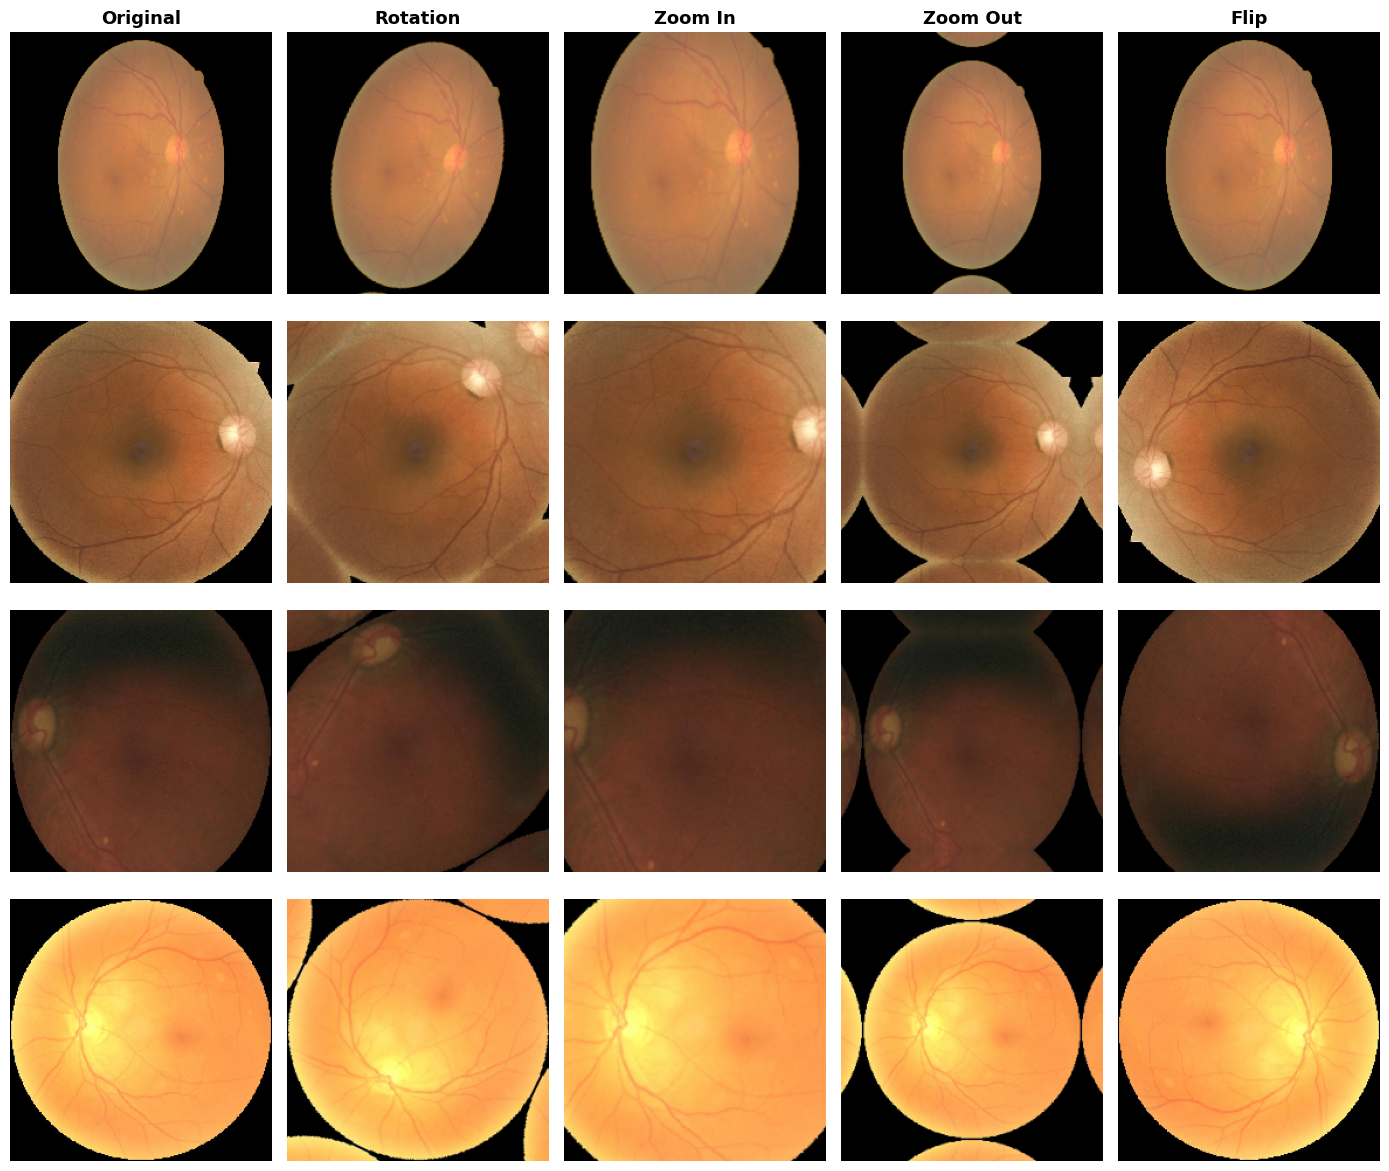

In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# 🔹 Dataset path
dataset_path = '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset'

# 🔹 Augmentation layers
rotation = tf.keras.layers.RandomRotation(0.2)

zoom_in = tf.keras.layers.RandomZoom(
    height_factor=(-0.2, -0.2), 
    width_factor=(-0.2, -0.2)
)

zoom_out = tf.keras.layers.RandomZoom(
    height_factor=(0.2, 0.2), 
    width_factor=(0.2, 0.2)
)

flip = tf.keras.layers.RandomFlip("horizontal_and_vertical")

# 🔹 Get class folders
classes = sorted([cls for cls in os.listdir(dataset_path) 
                  if os.path.isdir(os.path.join(dataset_path, cls))])

# 🔹 Load image
def load_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img) / 255.0
    return np.expand_dims(img, axis=0)

# 🔹 Plot setup
rows = len(classes)
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
fig.patch.set_facecolor('white')

column_titles = ["Original", "Rotation", "Zoom In", "Zoom Out", "Flip"]

# 🔹 Set column titles
for j in range(cols):
    axes[0, j].set_title(column_titles[j], fontsize=13, fontweight='bold')

# 🔹 Loop through classes
for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = load_image(img_path)

    imgs = [
        img,
        rotation(img, training=True),
        zoom_in(img, training=True),
        zoom_out(img, training=True),
        flip(img, training=True)
    ]

    for j in range(cols):
        axes[i, j].imshow(np.squeeze(imgs[j]))
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

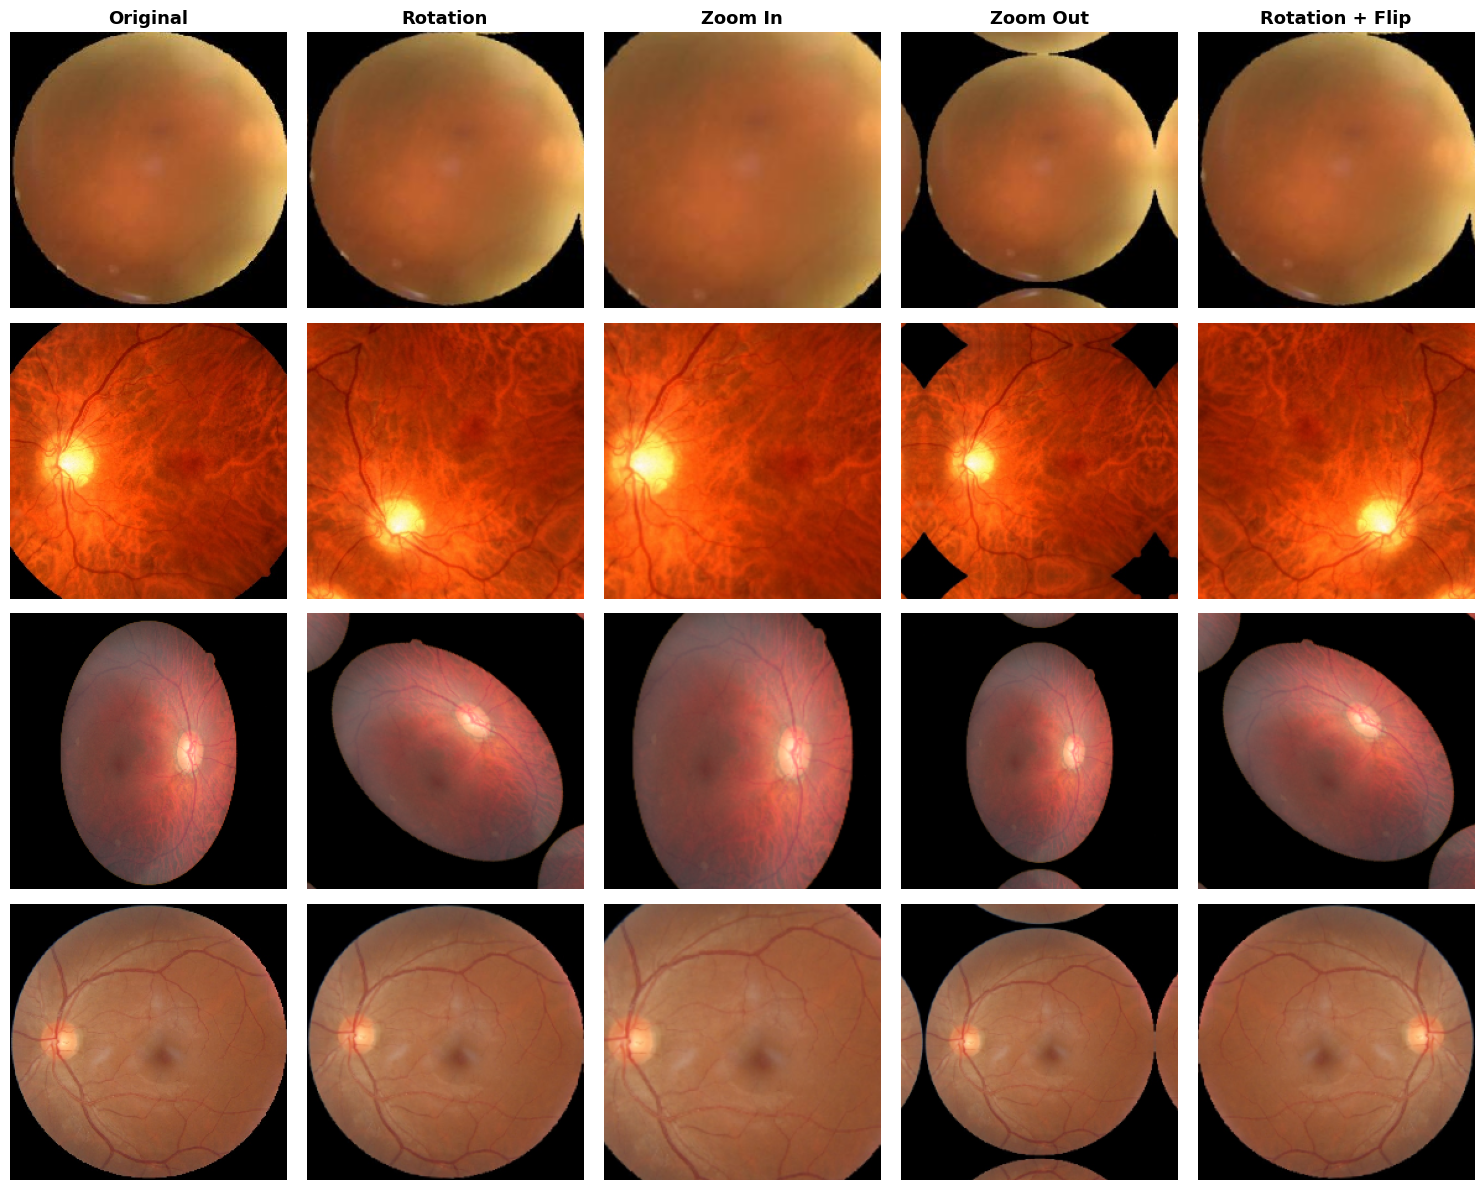

In [5]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image

# 🔹 Dataset path
dataset_path = '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset'

# 🔹 Augmentation layers
rotation = tf.keras.layers.RandomRotation(0.2)

zoom_in = tf.keras.layers.RandomZoom(
    height_factor=(-0.2, -0.2),
    width_factor=(-0.2, -0.2)
)

zoom_out = tf.keras.layers.RandomZoom(
    height_factor=(0.2, 0.2),
    width_factor=(0.2, 0.2)
)

flip = tf.keras.layers.RandomFlip("horizontal")

# 🔹 Get class folders
classes = sorted([
    cls for cls in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, cls))
])

# 🔹 Load image function
def load_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img = image.img_to_array(img) / 255.0
    return np.expand_dims(img, axis=0)

# 🔹 Plot setup
rows = len(classes)
cols = 5  # Original, Rotation, Zoom In, Zoom Out, Rotation+Flip

fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
fig.patch.set_facecolor('white')

column_titles = ["Original", "Rotation", "Zoom In", "Zoom Out", "Rotation + Flip"]

# 🔹 Set column titles
for j in range(cols):
    axes[0, j].set_title(column_titles[j], fontsize=13, fontweight='bold')

# 🔹 Loop through classes
for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = load_image(img_path)

    # 🔥 Apply transformations
    rotated = rotation(img, training=True)
    zin = zoom_in(img, training=True)
    zout = zoom_out(img, training=True)

    # 🔥 Combined transformation (visible change)
    rot_flip = flip(rotated, training=True)

    imgs = [img, rotated, zin, zout, rot_flip]

    for j in range(cols):
        axes[i, j].imshow(np.squeeze(imgs[j]))
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [6]:
import os
import shutil
import random

# 🔹 Original dataset path
dataset_path = '/kaggle/input/datasets/gunavenkatdoddi/eye-diseases-classification/dataset'

# 🔹 New output path (writeable in Kaggle)
output_path = '/kaggle/working/eye_split'

# 🔹 Split ratio
train_ratio = 0.8
val_ratio = 0.1
test_ratio = 0.1

# 🔹 Create folders
for split in ['train', 'val', 'test']:
    for class_name in os.listdir(dataset_path):
        class_path = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_path):
            os.makedirs(os.path.join(output_path, split, class_name), exist_ok=True)

# 🔹 Split dataset
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)

    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]

    # 🔹 Copy files
    for img in train_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path, 'train', class_name, img))

    for img in val_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path, 'val', class_name, img))

    for img in test_imgs:
        shutil.copy(os.path.join(class_path, img),
                    os.path.join(output_path, 'test', class_name, img))

print("✅ Dataset split completed successfully!")

✅ Dataset split completed successfully!


In [7]:
for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()} SET:")
    for class_name in os.listdir(os.path.join(output_path, split)):
        count = len(os.listdir(os.path.join(output_path, split, class_name)))
        print(f"{class_name}: {count}")


TRAIN SET:
normal: 859
cataract: 830
glaucoma: 805
diabetic_retinopathy: 878

VAL SET:
normal: 107
cataract: 104
glaucoma: 101
diabetic_retinopathy: 110

TEST SET:
normal: 108
cataract: 104
glaucoma: 101
diabetic_retinopathy: 110


In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🔹 Paths
train_path = '/kaggle/working/eye_split/train'
val_path   = '/kaggle/working/eye_split/val'
test_path  = '/kaggle/working/eye_split/test'

# 🔥 Resolution (helps fundus details)
IMG_SIZE = (256, 256)
BATCH_SIZE = 16

# 🔥 Use VGG16 preprocessing (IMPORTANT)
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.20,
    horizontal_flip=True,
    width_shift_range=0.08,
    height_shift_range=0.08,
    brightness_range=[0.85, 1.15]
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    train_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)
val_gen = val_datagen.flow_from_directory(
    val_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical'
)
test_gen = test_datagen.flow_from_directory(
    test_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

# 🔥 Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))

# 🔹 Base model
base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

# 🔥 Fine-tune last 8 layers (balanced)
for layer in base_model.layers[:-8]:
    layer.trainable = False
for layer in base_model.layers[-8:]:
    layer.trainable = True

# 🔥 Regularized head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(64, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# 🔥 Cosine LR schedule over exactly 20 epochs
steps_per_epoch = len(train_gen)
total_steps = steps_per_epoch * 20

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=2e-5,
    decay_steps=total_steps,
    alpha=1e-6
)

model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# 🔹 (Optional) label smoothing already in loss; no EarlyStopping (run full 20)
callbacks = []

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks
)

# 🔹 Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

Found 3372 images belonging to 4 classes.
Found 422 images belonging to 4 classes.
Found 423 images belonging to 4 classes.
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


I0000 00:00:1777569454.939527      83 service.cc:152] XLA service 0x18b500e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777569454.939579      83 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777569454.939585      83 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777569455.860778      83 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777569475.460333      83 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 46/211 ━━━━━━━━━━━━━━━━━━━━ 1:02 380ms/step - accuracy: 0.2742 - loss: 2.5220

...

211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.3716 - loss: 2.1648

2026-04-30 17:19:46.140068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 17:19:46.379273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 17:19:47.632729: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 17:19:47.964188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


211/211 ━━━━━━━━━━━━━━━━━━━━ 139s 549ms/step - accuracy: 0.3720 - loss: 2.1634 - val_accuracy: 0.6066 - val_loss: 1.4002
Epoch 2/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 81s 385ms/step - accuracy: 0.6075 - loss: 1.5541 - val_accuracy: 0.7441 - val_loss: 1.2815
Epoch 3/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 81s 382ms/step - accuracy: 0.6422 - loss: 1.4557 - val_accuracy: 0.8081 - val_loss: 1.1892
Epoch 4/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 80s 379ms/step - accuracy: 0.7009 - loss: 1.3713 - val_accuracy: 0.7251 - val_loss: 1.2687
Epoch 5/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 81s 382ms/step - accuracy: 0.7458 - loss: 1.3109 - val_accuracy: 0.8531 - val_loss: 1.0890
Epoch 6/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 81s 384ms/step - accuracy: 0.7662 - loss: 1.2624 - val_accuracy: 0.8507 - val_loss: 1.1379
Epoch 7/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 80s 379ms/step - accuracy: 0.7959 - loss: 1.2211 - val_accuracy: 0.8839 - val_loss: 1.0564
Epoch 8/20
211/211 ━━━━━━━━━━━━━━━━━━━━ 82s 389ms/step - accuracy: 0.8367 - loss: 1.1606 - va

2026-04-30 17:45:46.210723: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 17:45:46.448108: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 17:45:47.770447: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 17:45:48.092967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 544ms/step - accuracy: 0.8710 - loss: 1.0814

✅ Test Accuracy: 0.9007


In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 🔹 Get predictions
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🔹 True labels
y_true = test_gen.classes

# 🔹 Class labels
class_labels = list(test_gen.class_indices.keys())

# 🔹 Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)

print("🔹 Classification Report:\n")
print(report)

27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 204ms/step
🔹 Classification Report:

                      precision    recall  f1-score   support

            cataract       0.96      0.86      0.90       104
diabetic_retinopathy       0.98      0.95      0.96       110
            glaucoma       0.92      0.84      0.88       101
              normal       0.78      0.95      0.86       108

            accuracy                           0.90       423
           macro avg       0.91      0.90      0.90       423
        weighted avg       0.91      0.90      0.90       423



In [10]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training(hist):
    # 🔹 Extract data
    tr_acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    tr_loss = hist.history['loss']
    val_loss = hist.history['val_loss']

    # 🔹 Best epochs
    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    epochs = np.arange(1, len(tr_acc) + 1)

    plt.figure(figsize=(18,6))

    # 🔥 LOSS
    plt.subplot(1,2,1)
    plt.plot(epochs, tr_loss, 'r-', label='Train Loss')
    plt.plot(epochs, val_loss, 'g-', label='Val Loss')

    plt.scatter(best_loss_epoch+1, val_loss[best_loss_epoch],
                color='blue', s=120,
                label=f'Best Epoch = {best_loss_epoch+1}')

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)

    # 🔥 ACCURACY
    plt.subplot(1,2,2)
    plt.plot(epochs, tr_acc, 'r-', label='Train Accuracy')
    plt.plot(epochs, val_acc, 'g-', label='Val Accuracy')

    plt.scatter(best_acc_epoch+1, val_acc[best_acc_epoch],
                color='blue', s=120,
                label=f'Best Epoch = {best_acc_epoch+1}')

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

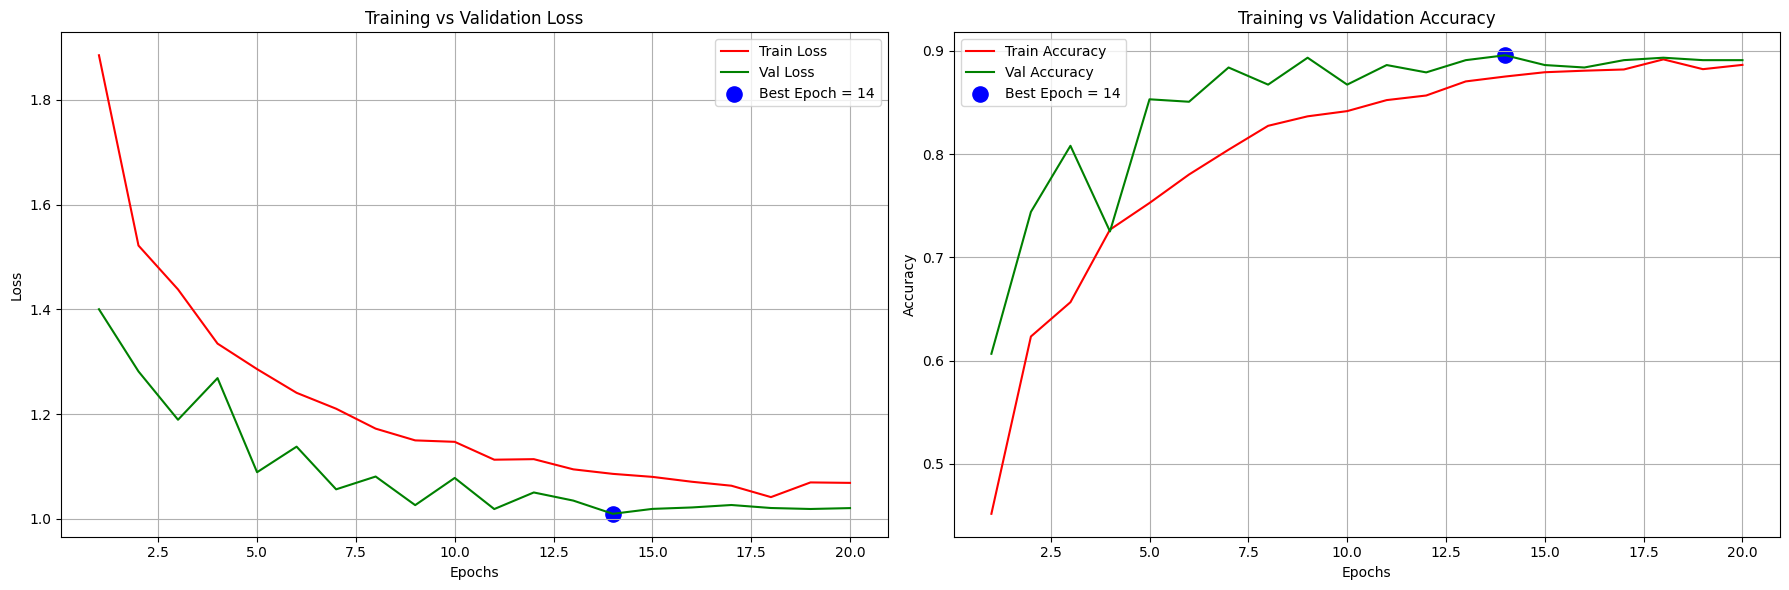

In [11]:
plot_training(history)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    '''
    This function plots a confusion matrix.
    Normalization can be applied by setting normalize=True.
    '''

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # 🔥 Normalize if needed
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("\nNormalized Confusion Matrix\n")
    else:
        print("\nConfusion Matrix (Without Normalization)\n")

    print(cm)

    # 🔥 Add values inside matrix
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i,
                 f"{cm[i, j]:.2f}" if normalize else int(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Confusion Matrix (Without Normalization)

[[ 89   0   6   9]
 [  0 104   0   6]
 [  2   0  85  14]
 [  2   2   1 103]]


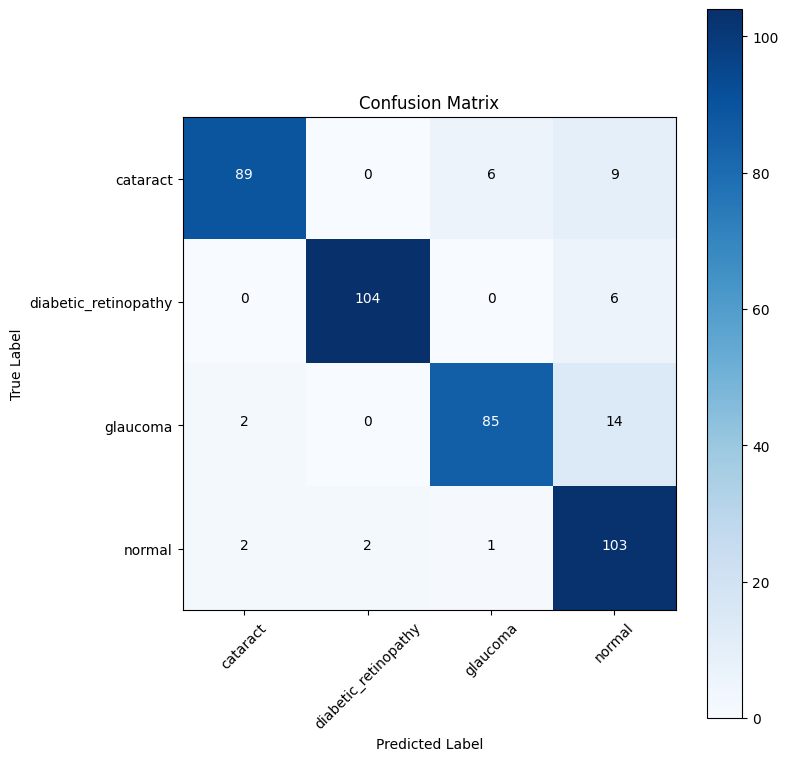


Normalized Confusion Matrix

[[0.85576923 0.         0.05769231 0.08653846]
 [0.         0.94545455 0.         0.05454545]
 [0.01980198 0.         0.84158416 0.13861386]
 [0.01851852 0.01851852 0.00925926 0.9537037 ]]


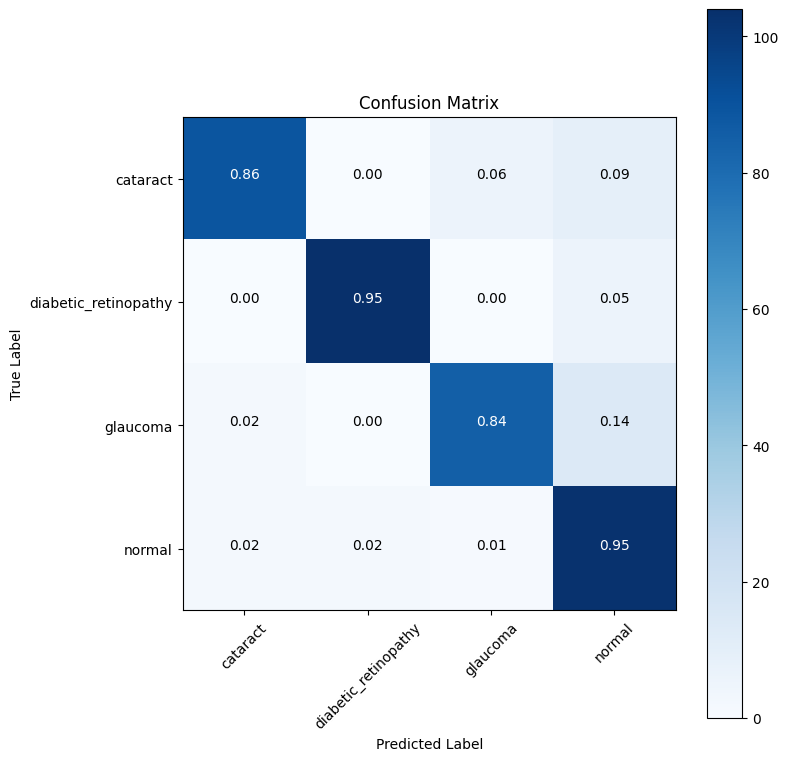

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

# 🔹 Normal
plot_confusion_matrix(cm, class_labels)

# 🔹 Normalized (recommended for paper)
plot_confusion_matrix(cm, class_labels, normalize=True)

In [14]:
#MobileNetV2

In [15]:
# 🔥 Imports
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 🔹 Paths
train_path = '/kaggle/working/eye_split/train'
val_path = '/kaggle/working/eye_split/val'
test_path = '/kaggle/working/eye_split/test'

# 🔥 Image settings
IMG_SIZE = (256, 256)
BATCH_SIZE = 32

# 🔥 Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.25,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_gen = val_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# 🔥 Class Weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))

# 🔹 Load MobileNetV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(256, 256, 3)
)

# 🔥 Fine-tune deeper layers
for layer in base_model.layers[:-100]:
    layer.trainable = False

for layer in base_model.layers[-100:]:
    layer.trainable = True

# 🔥 Custom Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(train_gen.num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# 🔥 Compile
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# 🔥 Callbacks (NO EarlyStopping → full 20 epochs)
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=3,
        factor=0.3,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_mobilenet.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    )
]

# 🔥 Train (FULL 20 EPOCHS)
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

# 🔥 Verify
print("\n✔ Epochs recorded:", len(history.history['accuracy']))

# 🔥 Load best model
model = tf.keras.models.load_model("best_mobilenet.keras")

# 🔹 Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

Found 3372 images belonging to 4 classes.
Found 422 images belonging to 4 classes.
Found 423 images belonging to 4 classes.


/tmp/ipykernel_23/707090383.py:63: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


...

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 905ms/step - accuracy: 0.3613 - loss: 1.8614

2026-04-30 17:48:48.589954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 17:48:48.727419: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


106/106 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.3619 - loss: 1.8590 - val_accuracy: 0.2583 - val_loss: 1.8199 - learning_rate: 3.0000e-05
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 75s 711ms/step - accuracy: 0.6011 - loss: 1.2151 - val_accuracy: 0.2915 - val_loss: 1.8451 - learning_rate: 3.0000e-05
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 74s 696ms/step - accuracy: 0.6436 - loss: 1.0758 - val_accuracy: 0.3886 - val_loss: 1.6568 - learning_rate: 3.0000e-05
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 686ms/step - accuracy: 0.7100 - loss: 1.0032 - val_accuracy: 0.4953 - val_loss: 1.4746 - learning_rate: 3.0000e-05
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 75s 707ms/step - accuracy: 0.7236 - loss: 0.9345 - val_accuracy: 0.5166 - val_loss: 1.4013 - learning_rate: 3.0000e-05
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 75s 703ms/step - accuracy: 0.7358 - loss: 0.9227 - val_accuracy: 0.5900 - val_loss: 1.2211 - learning_rate: 3.0000e-05
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 73s 692ms/step - ac

2026-04-30 18:12:55.817533: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:12:55.955058: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:12:56.091430: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


14/14 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9143 - loss: 0.5853

✅ Test Accuracy: 0.8889


In [16]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Get predictions
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🔹 True labels
y_true = test_gen.classes

# 🔹 Class names (IMPORTANT: correct order)
class_labels = list(test_gen.class_indices.keys())

# 🔹 Classification Report
print("\n🔹 Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 685ms/step

🔹 Classification Report:

                      precision    recall  f1-score   support

            cataract       0.88      0.93      0.91       104
diabetic_retinopathy       0.95      0.96      0.96       110
            glaucoma       0.87      0.82      0.85       101
              normal       0.84      0.83      0.84       108

            accuracy                           0.89       423
           macro avg       0.89      0.89      0.89       423
        weighted avg       0.89      0.89      0.89       423



In [17]:
import numpy as np
import matplotlib.pyplot as plt
import itertools

def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    '''
    This function plots a confusion matrix.
    Normalization can be applied by setting normalize=True.
    '''

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # 🔥 Normalize if needed
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("\nNormalized Confusion Matrix\n")
    else:
        print("\nConfusion Matrix (Without Normalization)\n")

    print(cm)

    # 🔥 Add values inside matrix
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i,
                 f"{cm[i, j]:.2f}" if normalize else int(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Confusion Matrix (Without Normalization)

[[ 97   0   2   5]
 [  0 106   0   4]
 [  9   1  83   8]
 [  4   4  10  90]]


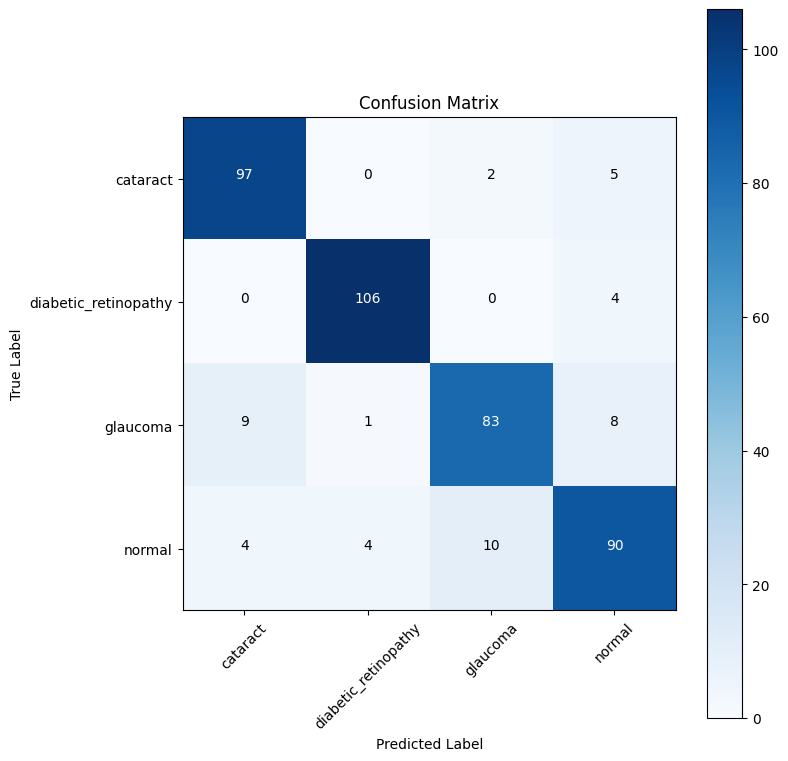


Normalized Confusion Matrix

[[0.93269231 0.         0.01923077 0.04807692]
 [0.         0.96363636 0.         0.03636364]
 [0.08910891 0.00990099 0.82178218 0.07920792]
 [0.03703704 0.03703704 0.09259259 0.83333333]]


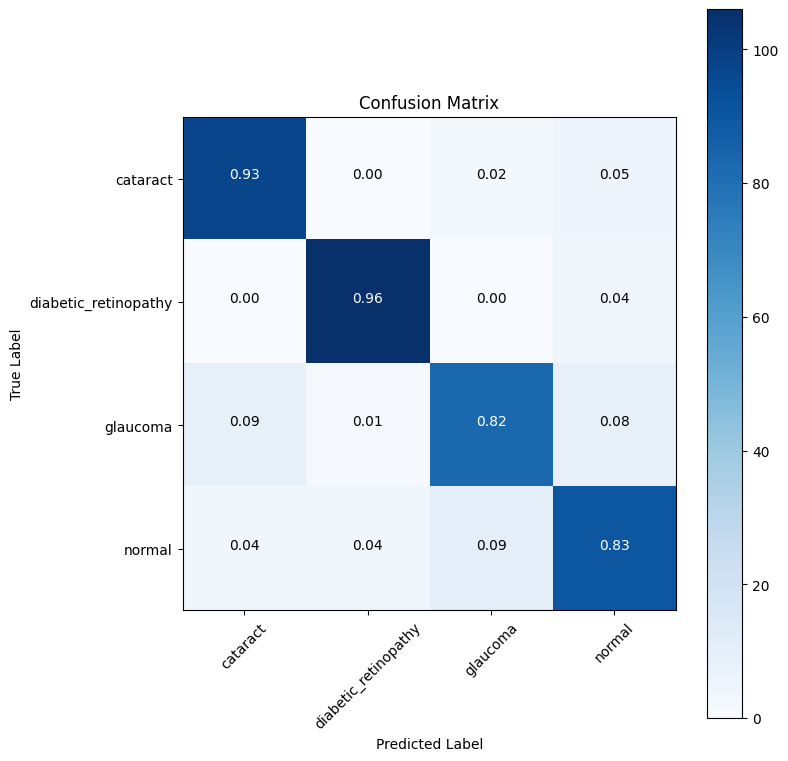

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

# 🔹 Normal
plot_confusion_matrix(cm, class_labels)

# 🔹 Normalized (recommended for paper)
plot_confusion_matrix(cm, class_labels, normalize=True)

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_training(history):
    
    # 🔹 Extract values safely
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])

    epochs = np.arange(1, len(acc) + 1)

    # 🔹 Best epochs
    best_acc_epoch = np.argmax(val_acc)
    best_loss_epoch = np.argmin(val_loss)

    # 🔥 Plot
    plt.figure(figsize=(18,6))

    # 🔴 LOSS (same colors as reference)
    plt.subplot(1,2,1)
    plt.plot(epochs, loss, 'r-', label='Train Loss')        # 🔴 red
    plt.plot(epochs, val_loss, 'g-', label='Val Loss')      # 🟢 green

    plt.scatter(best_loss_epoch+1, val_loss[best_loss_epoch],
                color='blue', s=120,                       # 🔵 blue
                label=f'Best Epoch = {best_loss_epoch+1}')

    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)

    # 🔴 ACCURACY (same colors as reference)
    plt.subplot(1,2,2)
    plt.plot(epochs, acc, 'r-', label='Train Accuracy')     # 🔴 red
    plt.plot(epochs, val_acc, 'g-', label='Val Accuracy')   # 🟢 green

    plt.scatter(best_acc_epoch+1, val_acc[best_acc_epoch],
                color='blue', s=120,                       # 🔵 blue
                label=f'Best Epoch = {best_acc_epoch+1}')

    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

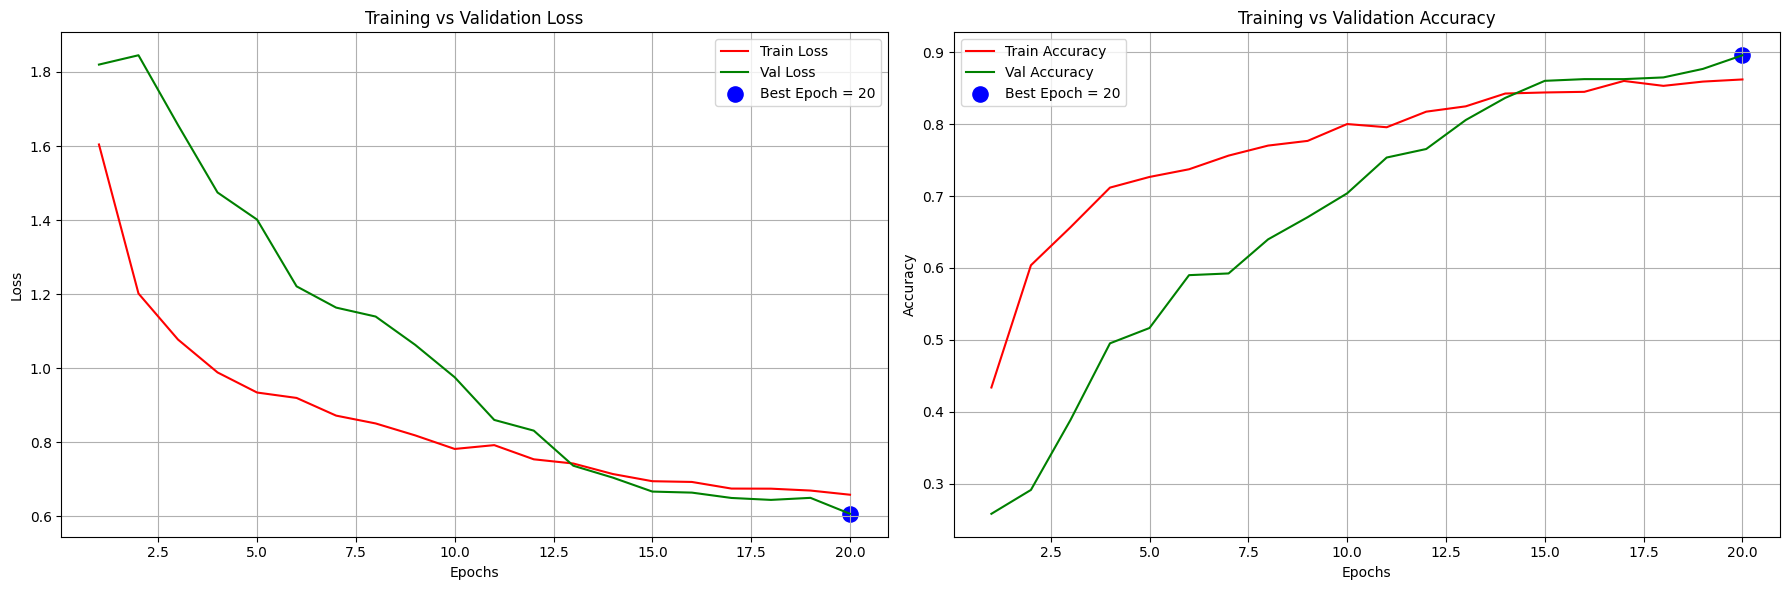

In [20]:
plot_training(history)

In [21]:
# 🔥 SUPPRESS LOGS
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# 🔹 Imports
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Paths
train_path = '/kaggle/working/eye_split/train'
val_path   = '/kaggle/working/eye_split/val'
test_path  = '/kaggle/working/eye_split/test'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 🔥 Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path, image_size=IMG_SIZE, batch_size=BATCH_SIZE, shuffle=False
)

class_names = train_ds.class_names

# 🔥 Preprocess + Augment
def preprocess(x, y):
    return preprocess_input(x), y

def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.1)
    return x, y

train_ds = train_ds.map(augment).map(preprocess)
val_ds   = val_ds.map(preprocess)
test_ds  = test_ds.map(preprocess)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# 🔥 Class weights
labels = np.concatenate([y for x, y in train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

# 🔹 Model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 🔥 Fine-tuning
for layer in base_model.layers[:-30]:
    layer.trainable = False

# 🔥 Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(len(class_names), activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# 🔥 Compile
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# 🔥 Callbacks (NO early stopping → full 20 epochs)
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=2,
        factor=0.3,
        min_lr=1e-6
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_effnet.keras",
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=False,
        verbose=0
    )
]

# 🔥 FORCE FULL DATA PER EPOCH
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
validation_steps = tf.data.experimental.cardinality(val_ds).numpy()

# 🔥 TRAIN (STORE HISTORY)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# 🔥 VERIFY EPOCHS
print("\n✔ Epochs recorded:", len(history.history['accuracy']))

# 🔥 LOAD BEST MODEL
model = tf.keras.models.load_model("best_effnet.keras")

# 🔹 EVALUATE
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n🔥 FINAL TEST ACCURACY: {test_acc:.4f}")



Found 3372 files belonging to 4 classes.
Found 422 files belonging to 4 classes.
Found 423 files belonging to 4 classes.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


2026-04-30 18:14:02.970868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:03.114716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:03.472328: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:03.614209: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:04.445715: E external/local_xla/xla/stream_

 43/106 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.3340 - loss: 1.9607

2026-04-30 18:14:24.791998: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:24.930124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:25.250485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:25.391788: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:26.203780: E external/local_xla/xla/stream_

106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.4237 - loss: 1.6374

2026-04-30 18:14:52.044102: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:52.179807: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:52.490617: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:52.632049: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:14:53.414061: E external/local_xla/xla/stream_

106/106 ━━━━━━━━━━━━━━━━━━━━ 85s 407ms/step - accuracy: 0.4248 - loss: 1.6338 - val_accuracy: 0.7322 - val_loss: 0.8175 - learning_rate: 3.0000e-05
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.7195 - loss: 0.7510 - val_accuracy: 0.8365 - val_loss: 0.5124 - learning_rate: 3.0000e-05
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.7840 - loss: 0.5892 - val_accuracy: 0.8578 - val_loss: 0.3881 - learning_rate: 3.0000e-05
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.8277 - loss: 0.4883 - val_accuracy: 0.8863 - val_loss: 0.3314 - learning_rate: 3.0000e-05
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.8490 - loss: 0.4077 - val_accuracy: 0.9028 - val_loss: 0.3023 - learning_rate: 3.0000e-05
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.8773 - loss: 0.3560 - val_accuracy: 0.9100 - val_loss: 0.2829 - learning_rate: 3.0000e-05
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accura

2026-04-30 18:19:25.414731: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:19:25.550638: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:19:25.870424: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:19:26.012242: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-30 18:19:26.857051: E external/local_xla/xla/stream_


🔥 FINAL TEST ACCURACY: 0.8960


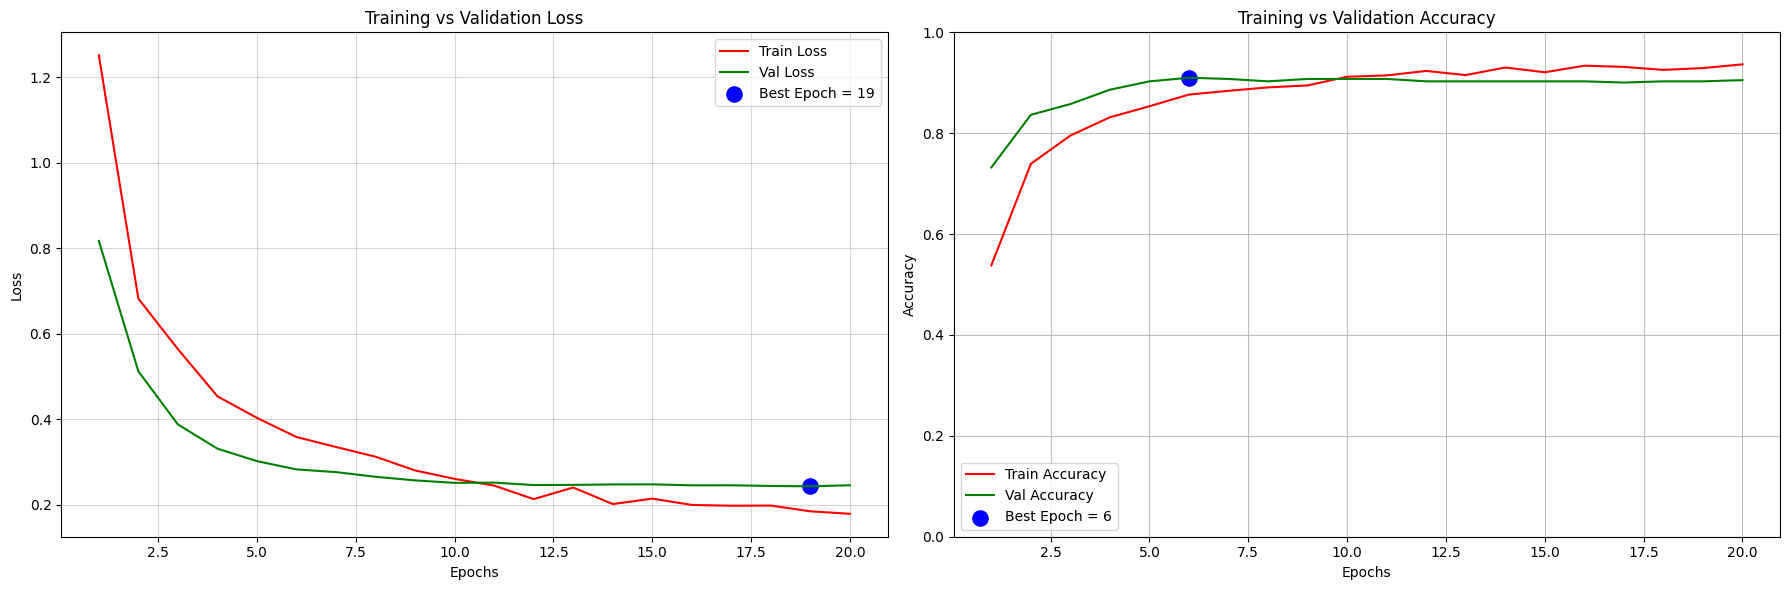

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# 🔹 Extract data
tr_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
tr_loss = history.history['loss']
val_loss = history.history['val_loss']

# 🔹 Best epochs
best_acc_epoch = np.argmax(val_acc)
best_loss_epoch = np.argmin(val_loss)

epochs = np.arange(1, len(tr_acc) + 1)

plt.figure(figsize=(18,6))

# 🔥 LOSS
plt.subplot(1,2,1)
plt.plot(epochs, tr_loss, 'r-', label='Train Loss')
plt.plot(epochs, val_loss, 'g-', label='Val Loss')

plt.scatter(best_loss_epoch+1, val_loss[best_loss_epoch],
            color='blue', s=120,
            label=f'Best Epoch = {best_loss_epoch+1}')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# ✅ uniform grid style
plt.grid(True, linestyle='-', alpha=0.5)


# 🔥 ACCURACY
plt.subplot(1,2,2)
plt.plot(epochs, tr_acc, 'r-', label='Train Accuracy')
plt.plot(epochs, val_acc, 'g-', label='Val Accuracy')

plt.scatter(best_acc_epoch+1, val_acc[best_acc_epoch],
            color='blue', s=120,
            label=f'Best Epoch = {best_acc_epoch+1}')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# ✅ FIX: control grid + ticks
plt.grid(True, linestyle='-', alpha=0.8)

# 🔥 optional (makes it look identical visually)
plt.ylim(0, 1)   # normalize axis like loss perception

plt.tight_layout()
plt.show()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title='Confusion Matrix',
                          cmap=plt.cm.Blues):
    '''
    This function computes and plots a confusion matrix.
    '''

    # 🔹 Compute matrix
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # 🔥 Normalize option
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("\nNormalized Confusion Matrix\n")
    else:
        print("\nConfusion Matrix (Without Normalization)\n")

    print(cm)

    # 🔥 Add values inside matrix
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i,
                 f"{cm[i, j]:.2f}" if normalize else int(cm[i, j]),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Confusion Matrix (Without Normalization)

[[ 91   0   6   7]
 [  0 107   2   1]
 [  5   1  84  11]
 [  2   1   8  97]]


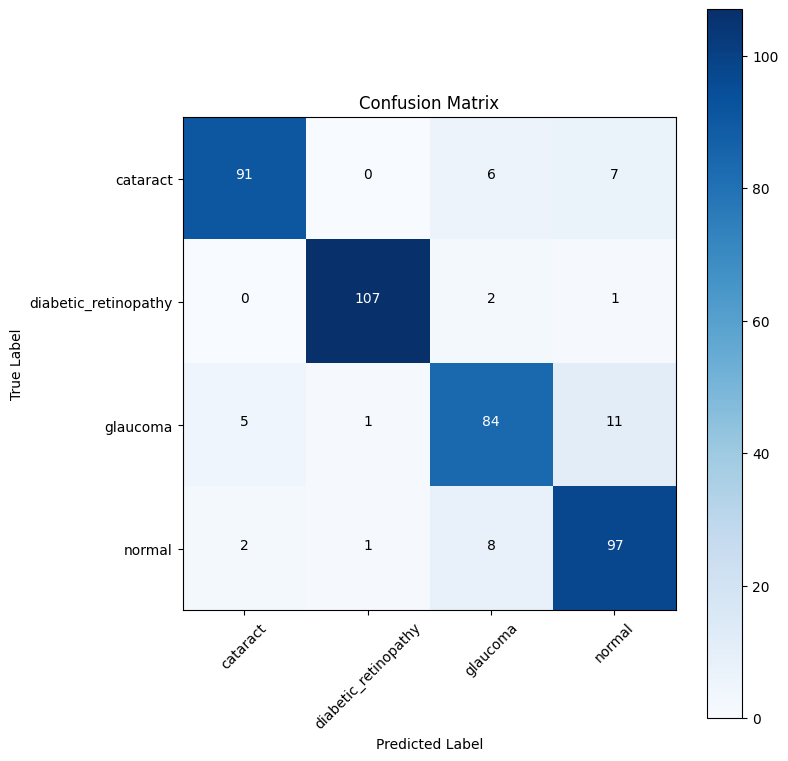


Normalized Confusion Matrix

[[0.875      0.         0.05769231 0.06730769]
 [0.         0.97272727 0.01818182 0.00909091]
 [0.04950495 0.00990099 0.83168317 0.10891089]
 [0.01851852 0.00925926 0.07407407 0.89814815]]


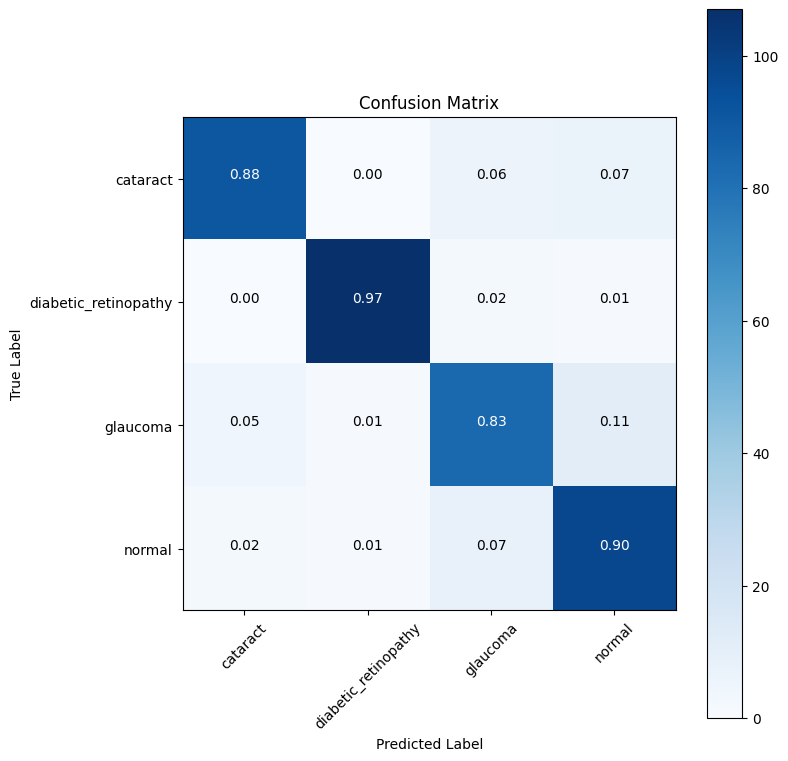

In [24]:
# 🔹 Predictions
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🔹 True labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# 🔹 Class names
classes = class_names

# 🔹 Plot
plot_confusion_matrix(y_true, y_pred, classes)

plot_confusion_matrix(y_true, y_pred, classes, normalize=True)

In [25]:
from sklearn.metrics import classification_report
import numpy as np

# 🔹 Predictions
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🔹 True labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# 🔹 Class labels
class_labels = class_names

# 🔹 Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("\n🔹 Classification Report:\n")
print(report)


🔹 Classification Report:

                      precision    recall  f1-score   support

            cataract       0.93      0.88      0.90       104
diabetic_retinopathy       0.98      0.97      0.98       110
            glaucoma       0.84      0.83      0.84       101
              normal       0.84      0.90      0.87       108

            accuracy                           0.90       423
           macro avg       0.90      0.89      0.90       423
        weighted avg       0.90      0.90      0.90       423

